
# LPT snapshots: density and power spectra

Generate three LPT snapshots (a = 0.1, 0.3, 0.5), paint 3D densities and spherical maps, compute 3D power spectra via class methods, and visualize density slices, P(k), spherical maps, and Cl.


In [1]:

import os
os.environ.setdefault("JAX_PLATFORM_NAME", "cpu")

import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt

from fwd_model_tools.probabilistic_models.full_field_model import Planck18
from fwd_model_tools.initial import gaussian_initial_conditions
from fwd_model_tools.pm import lpt
from fwd_model_tools.fields.density import DensityField , SphericalDensity

ERROR:2025-11-25 01:54:38,097:jax._src.xla_bridge:473: Jax plugin configuration error: Exception when calling jax_plugins.xla_cuda12.initialize()
Traceback (most recent call last):
  File "/home/wassim/micromamba/envs/AAI11/lib/python3.11/site-packages/jax/_src/xla_bridge.py", line 471, in discover_pjrt_plugins
    plugin_module.initialize()
  File "/home/wassim/micromamba/envs/AAI11/lib/python3.11/site-packages/jax_plugins/xla_cuda12/__init__.py", line 328, in initialize
    _check_cuda_versions(raise_on_first_error=True)
  File "/home/wassim/micromamba/envs/AAI11/lib/python3.11/site-packages/jax_plugins/xla_cuda12/__init__.py", line 285, in _check_cuda_versions
    local_device_count = cuda_versions.cuda_device_count()
                         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
RuntimeError: jaxlib/cuda/versions_helpers.cc:113: operation cuInit(0) failed: CUDA_ERROR_OPERATING_SYSTEM


JAX is not using 64-bit precision. This will dramatically affect numerical precision at even moderate L.


In [2]:

# Parameters
mesh_size = (64, 64, 64)
box_size = (200.0, 200.0, 200.0)
scale_factors = [0.1, 0.3, 0.5]
seed = 0
flatsky_npix = (128, 128)
field_size_deg = 10.0
field_size_rad = np.deg2rad(field_size_deg)
pixel_size = field_size_rad / flatsky_npix[0]
plane_width = box_size[2] / mesh_size[2]
plane_center = box_size[2] / 2
cosmo = Planck18()
key = jax.random.PRNGKey(seed)


In [3]:

# Initial conditions
init_field = gaussian_initial_conditions(
    key=key,
    mesh_size=mesh_size,
    box_size=box_size,
    cosmo=cosmo,
    flatsky_npix=flatsky_npix,
    nside=32,
)


shape of initial force: (64, 64, 64, 3)
growth factor shape: (1,)


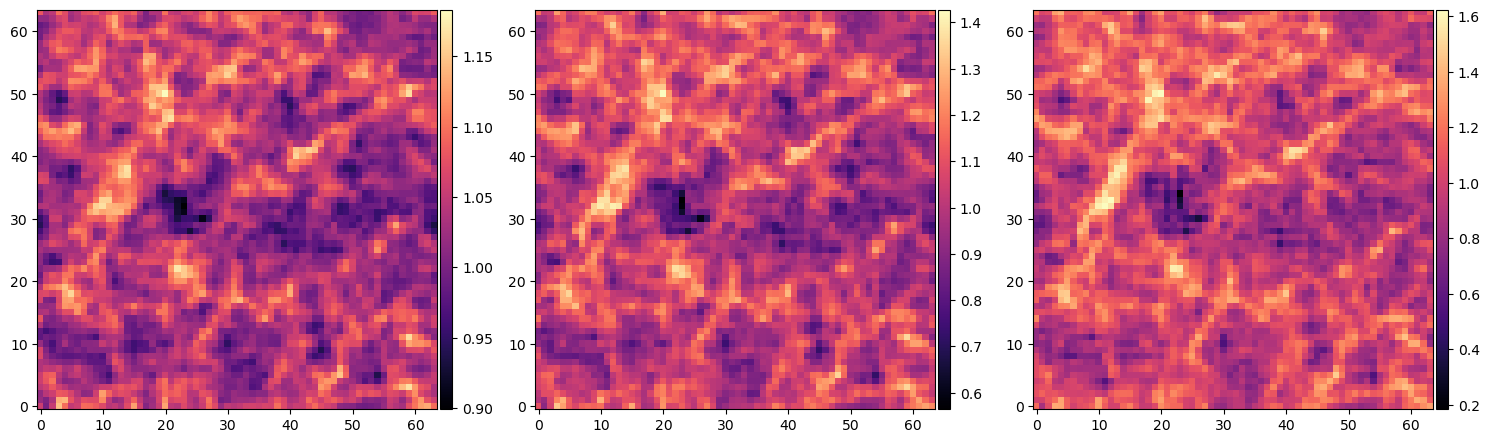

In [4]:

# LPT displacements
lpt_displacements = []
for a in scale_factors:
    dx_field, _ = lpt(cosmo, init_field, a=a, order=1)
    lpt_displacements.append(dx_field)

# Paint 3D densities
densities = DensityField.stack([dx.paint(mode="relative") for dx in lpt_displacements])

# Paint spherical maps
spherical_maps = SphericalDensity.stack(
    [
    dx.paint_spherical(
        center=plane_center,
        density_plane_width=plane_width,
        paint_nside=init_field.nside,
        mode="relative",
    )
    for dx in lpt_displacements
])
densities.show()


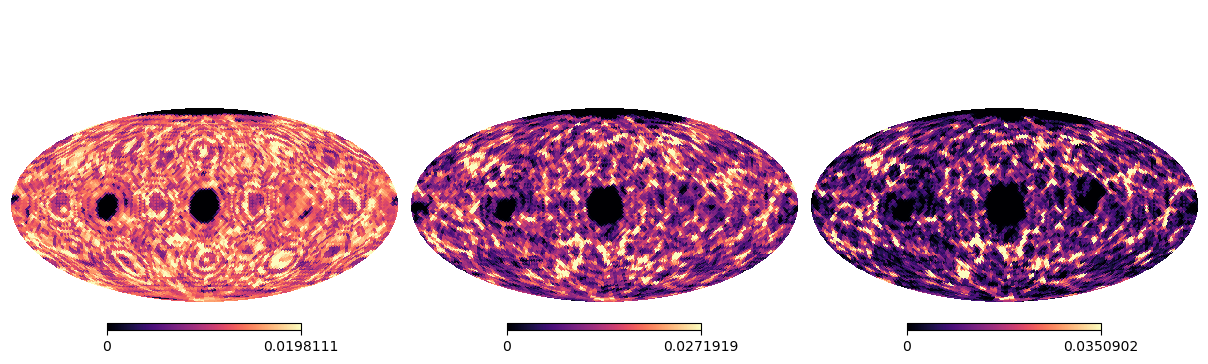

In [5]:
spherical_maps.show()

In [6]:

# Power spectra via class method
power_specs = densities.power()
cl = spherical_maps.angular_cl()


shape of data1: (3, 64, 64, 64)
shape of data1 after adding batch dim: (3, 64, 64, 64)
shape of k: (14,), shape of pk: (3, 14)


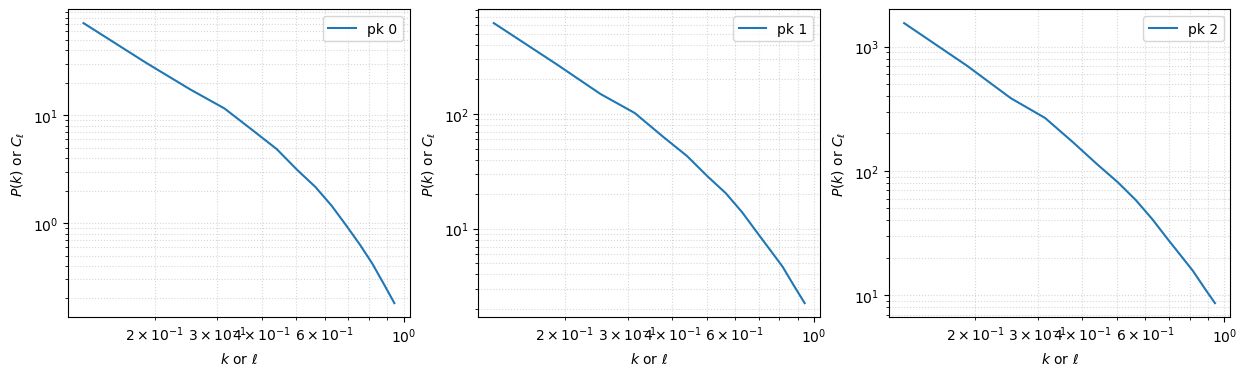

In [7]:
power_specs.show()

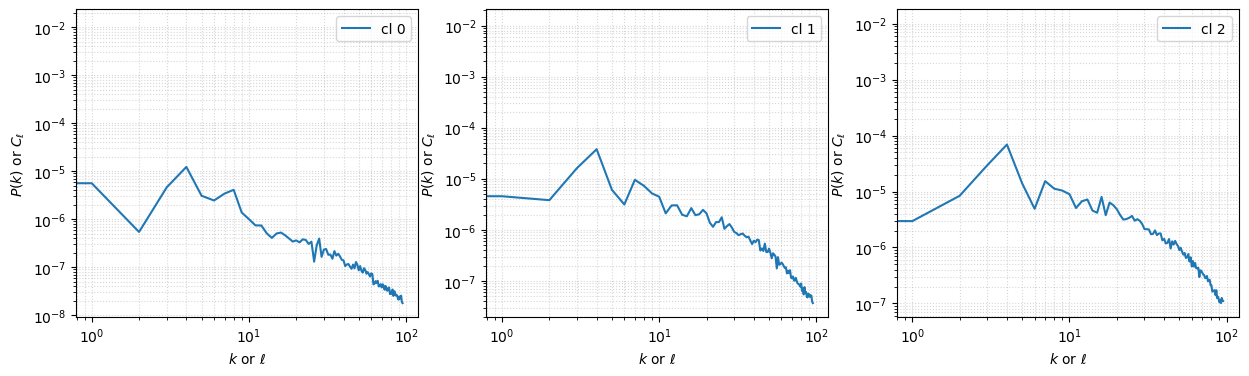

In [8]:
cl.show()

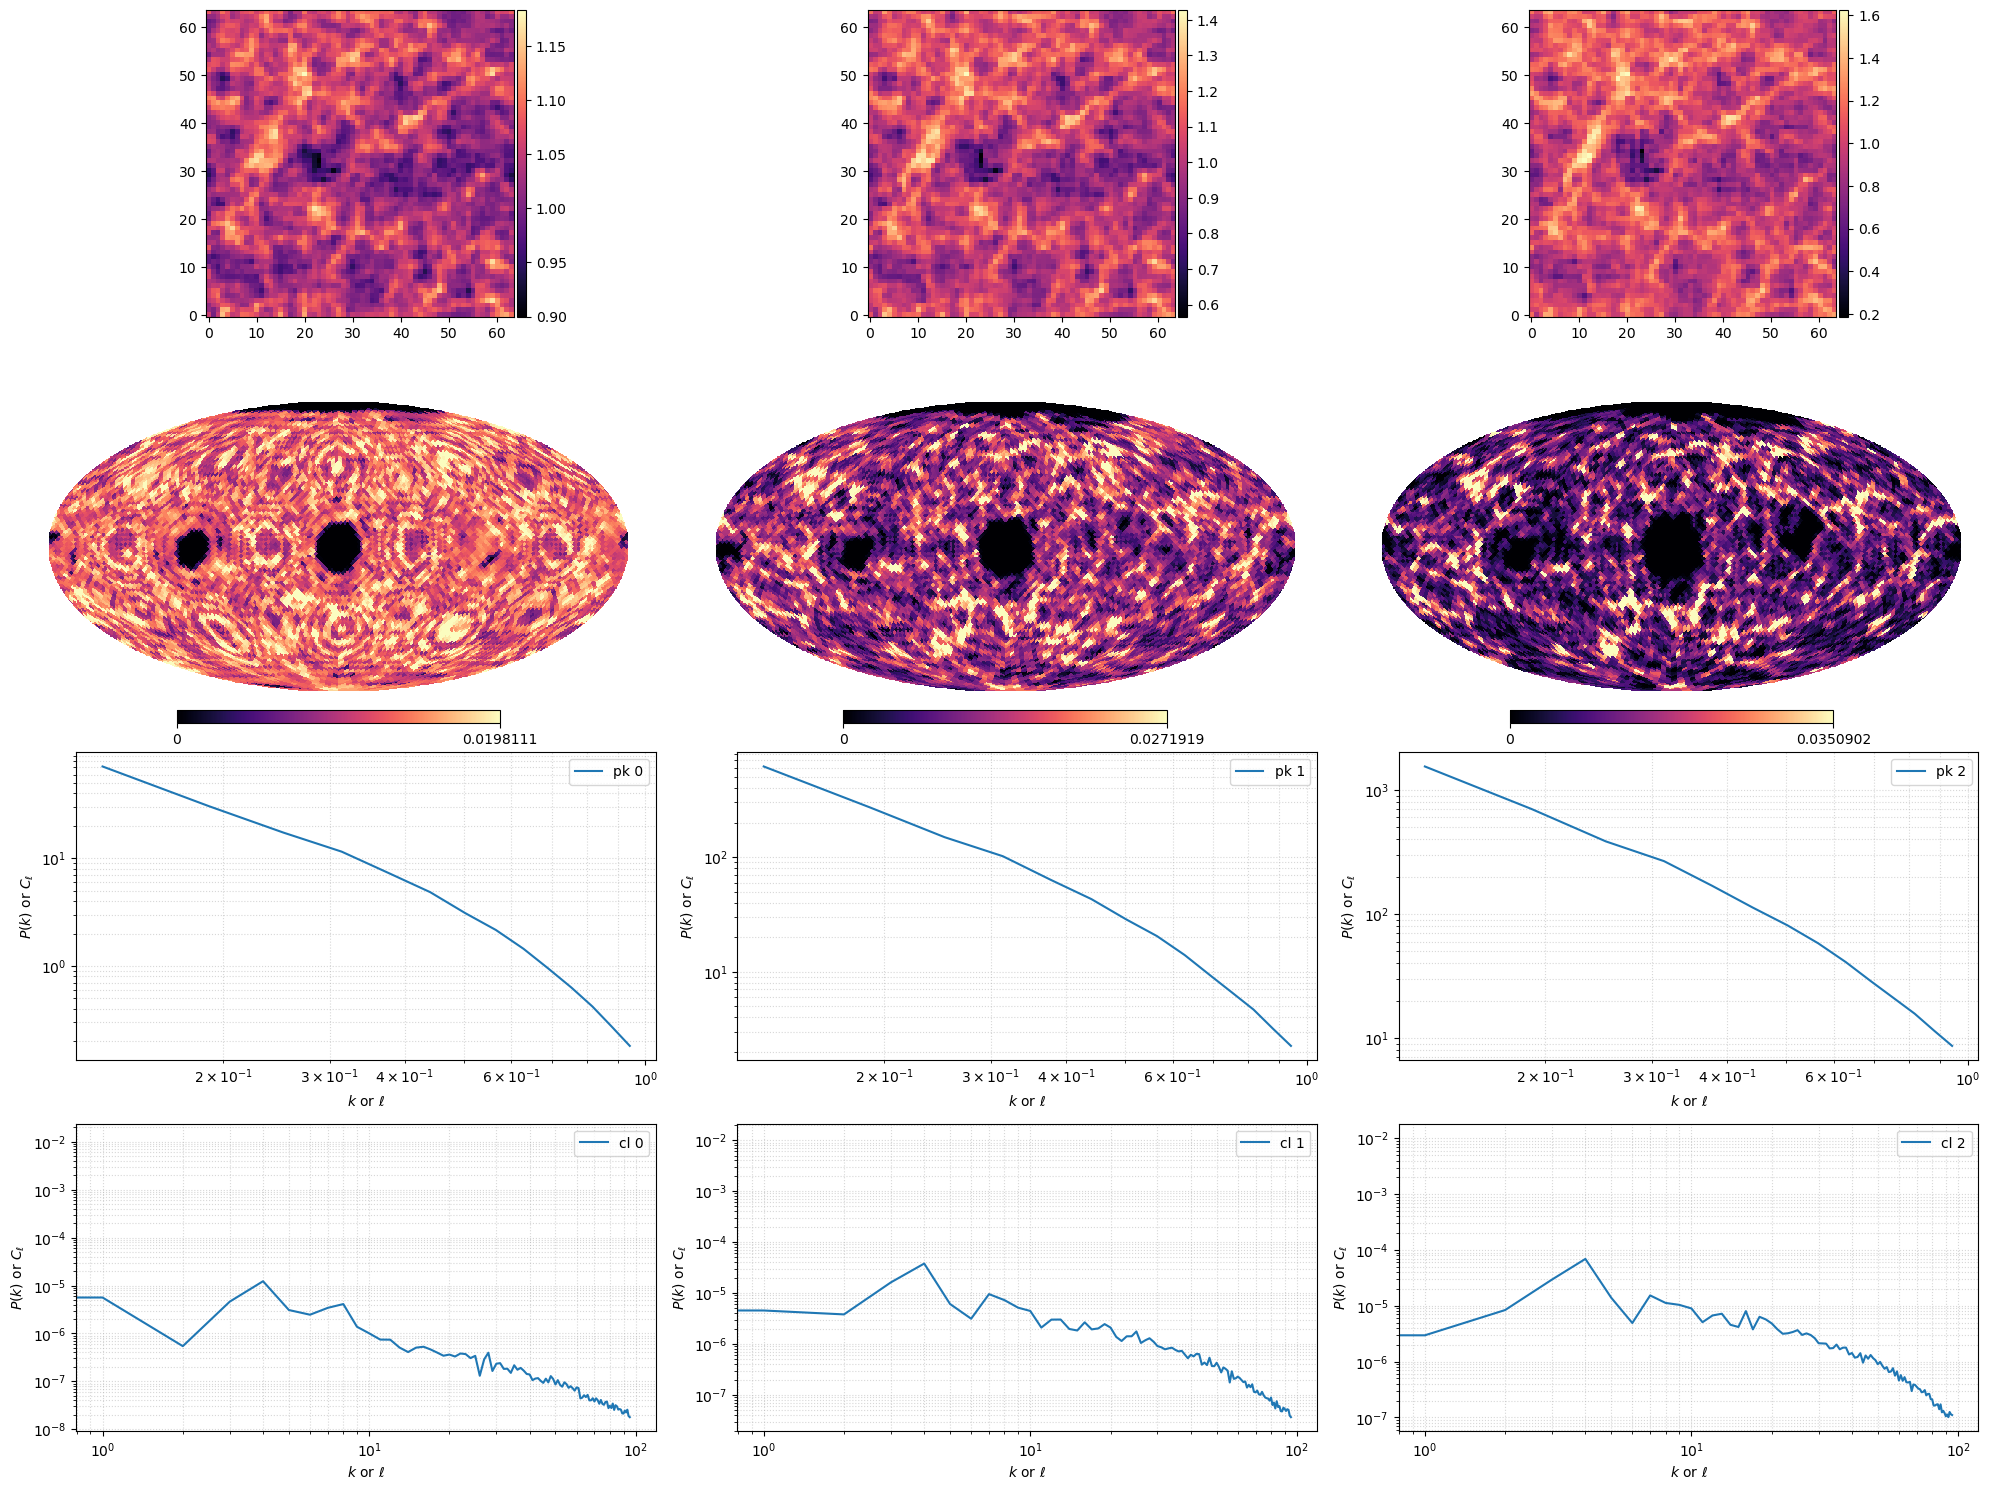

In [9]:
figure , axes = plt.subplots(4 ,3 , figsize = (20 , 15) )

densities.project().plot(ax=axes[0,:])
spherical_maps.plot(ax=axes[1,:])
power_specs.plot(ax=axes[2,:])
cl.plot(ax=axes[3,:])
plt.tight_layout()
plt.show()